In [1]:
#Projekt - analiza i wizualizacja danych w Pythonie


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
df = pd.read_csv("bank.csv")
#dane wczytane

df.head(5)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [4]:
df.isna().any()

age          False
job          False
marital      False
education    False
default      False
balance      False
housing      False
loan         False
contact      False
day          False
month        False
duration     False
campaign     False
pdays        False
previous     False
poutcome     False
deposit      False
dtype: bool

wszystkie kolumny nie zawierają braków danych
wartosci unkown w contact wynika po prostu z braku kontaktu z klientem a nie braku danych
wartosc unkown w poutcome wynika z braku kontaktu w poprzedniej kampanii a nie z braku dnaych

In [5]:
#dla osob ktore odmowily
sredni_czas_rozmowy_odmowa = df[df['deposit'] == "no"]['duration'].mean()
print(sredni_czas_rozmowy_odmowa)

#dla osob ktore sie zgodzily
sredni_czas_rozmowy_zgoda = df[df['deposit'] == "yes"]['duration'].mean()
print(sredni_czas_rozmowy_zgoda)

223.130257108803
537.2945736434109


Text(0, 0.5, 'liczba klientow')

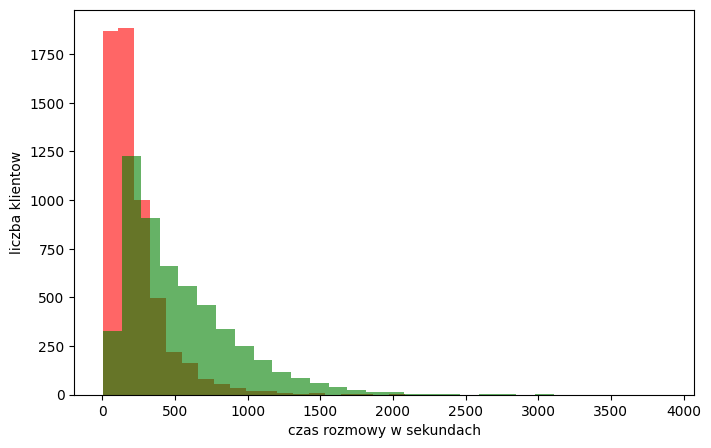

In [35]:
czas_rozmowy_odmowa = df[df['deposit'] == 'no']['duration']
czas_rozmowy_zgoda = df[df['deposit'] == 'yes']['duration']

plt.figure(figsize=(8, 5))
plt.hist(czas_rozmowy_odmowa, bins=30, alpha=0.6, color='red')
plt.hist(czas_rozmowy_zgoda, bins=30, alpha=0.6, color='green')
plt.xlabel('czas rozmowy w sekundach')
plt.ylabel('liczba klientow')




Jak widzimy sredni czas rozmowy dla osob ktore zgodzily sie wplacic depozyt wynosi 537 a dla osob ktore nie wplacily 223 co pokazuje ze dluzsza rozmowa z klientem zwieksza szanse na wplate pieniedzy na lokate  
Na wykresie widac ze im dluzszy czas rozmowy jest tym wiecej klientow zgadza sie na lokate  
  
    
Mozna powiedziec, ze instytucja finansowa powinna starac się jak najdluzej rozmaiwac z potencjalnym klientem aby zwiekszyc ilosc klientow zgadzajacych sie na lokate

In [7]:
#stan cywilny a decyzja o lokacie

osoby_rozwiedzione_zgoda = (len(df[(df['marital'] == 'divorced') & (df['deposit'] == 'yes')]) / len(df[df['marital'] == 'divorced'])) * 100
print(osoby_rozwiedzione_zgoda)

single_zgoda = (len(df[(df['marital'] == 'single') & (df['deposit'] == 'yes')]) / len(df[df['marital'] == 'single'])) * 100
print(single_zgoda)

malzenstwa_zgoda = (len(df[(df['marital'] == 'married') & (df['deposit'] == 'yes')]) / len(df[df['marital'] == 'married'])) * 100
print(malzenstwa_zgoda)


48.10518174787317
54.34906196702672
43.37899543378995


Text(0.5, 0, 'stan cywilny')

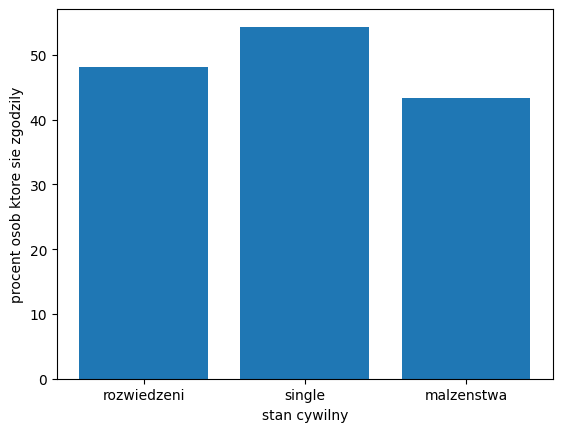

In [8]:
plt.bar(x = ['rozwiedzeni', 'single', 'malzenstwa'], height = [osoby_rozwiedzione_zgoda, single_zgoda, malzenstwa_zgoda])
plt.ylabel('procent osob ktore sie zgodzily')
plt.xlabel('stan cywilny')


Jak widac osoby które są singlami mają największe prawdopodbieństwo wpłacenia na lokate, ponieważ az 54% z nich to zrobiło, zaś jeżeli chodzi o grupę osob rozwiedzionych niecałe 50% wplaciło na lokatę. Jeżeli chodzi o małżeństwa jest to najmniej czyli lekko ponad 43%   
Podsumowując instytucja powinna szukać najlepiej kierować marketing do signli, i minimalizować marketing dla małżeństw

In [9]:
#badamy wpływ wykształcenia na decyzję o lokacie
wyksztalcenie_podstawowe_zgoda = (len(df[(df['education'] == 'primary') & (df['deposit'] == 'yes')]) / len(df[df['education'] == 'primary'])) * 100
print (wyksztalcenie_podstawowe_zgoda)
wyksztalcenie_srednie_zgoda = (len(df[(df['education'] == 'secondary') & (df['deposit'] == 'yes')]) / len(df[df['education'] == 'secondary'])) * 100
print (wyksztalcenie_srednie_zgoda)
wyksztalcenie_wyzsze_zgoda = (len(df[(df['education'] == 'tertiary') & (df['deposit'] == 'yes')]) / len(df[df['education'] == 'tertiary'])) * 100
print (wyksztalcenie_wyzsze_zgoda)


39.4
44.74068663257852
54.10680401192736


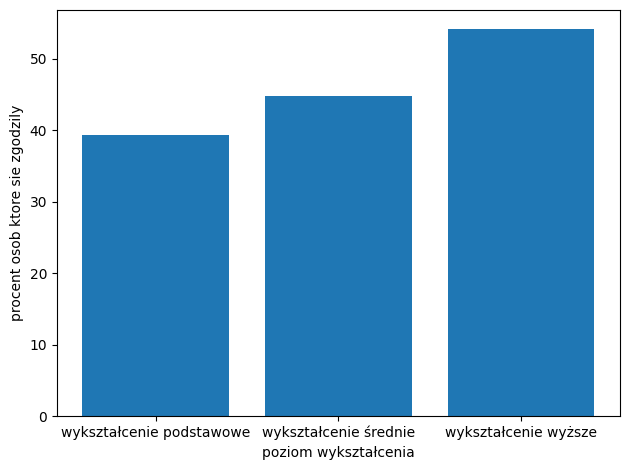

In [10]:


plt.bar(x = ['wykształcenie podstawowe', 'wykształcenie średnie', 'wykształcenie wyższe'], height = [wyksztalcenie_podstawowe_zgoda, wyksztalcenie_srednie_zgoda, wyksztalcenie_wyzsze_zgoda])
plt.ylabel('procent osob ktore sie zgodzily')
plt.xlabel('poziom wykształcenia')

#napisy sie na siebie nakldaja wiec trzeba poszerzyc wykres

plt.tight_layout()

Jak widac wyzej az 54% osob wyksztalconych wplacilo na lokate, niecale 45% z wyksztalceniem srednim wplacilo na lokate zas tylko 39% z wykształceniem podstawowym, może to wynikać z braku wiedzy na temat pieniądza i inwestycji więc instytucja powinna kierować głównie marketing w strone osób najbardziej wykształconych, ponieważ to u nich największą częścią są osoby wpłacające na lokatę 

In [11]:
#wplyw grupy wiekowej na decyzje o lokacie

mlody_zgoda = (len(df[(df['age'] <30) & (df['deposit'] == 'yes')]) / len(df[df['age'] <30])) * 100
print(mlody_zgoda)

sredni_wiek_zgoda = (len(df[(df['age'] >=30) & (df['age'] <60) & (df['deposit'] == 'yes')]) / len(df[(df['age'] >=30) & (df['age'] <60)])) * 100
print(sredni_wiek_zgoda)

starsi_zgoda = (len(df[(df['age'] >=60) & (df['deposit'] == 'yes')]) / len(df[df['age'] >=60])) * 100
print(starsi_zgoda)


59.83236621534493
42.588608311629486
76.92307692307693


jak widac najchetniej na lokate zgadzaja się osoby w starszej grupie wiekowej oraz ludzie mlodzi do lat 30, zas niechetni sa ludzie w wieku srednim, moze to wynikac z tego ze osoby mlode wiedza ze pieniadz lezacy na polce traci wartosc zas starsi ludzie sa podatni na namowy osob ktore wzbudzaja zaufanie. Ludzie w wieku srednim moga miec duze wydatki jak utrzymanie dzieci czy jakies kredyty przez co ich oszczednosci moga byc nieduze na tyle by oplacalo sie je wplacac na lokatę, wiec nasza instytucja powinna kierowac sie do mlodych jak i starszych a raczej mniej uwagi przykladac osobom w wieku srednim

In [ ]:
#wplyw zawodu na decyzje o lokacie

zawod_zgoda = df[df['deposit'] == 'yes'].groupby('job').size()

zawod_ogolem = df.groupby('job').size()

udzial_lokaty_w_zawodzie = (zawod_zgoda / zawod_ogolem) * 100
print(udzial_lokaty_w_zawodzie)


job
admin.           47.301349
blue-collar      36.419753
entrepreneur     37.500000
housemaid        39.781022
management       50.701481
retired          66.323907
self-employed    46.172840
services         39.978332
student          74.722222
technician       46.077894
unemployed       56.582633
unknown          48.571429
dtype: float64


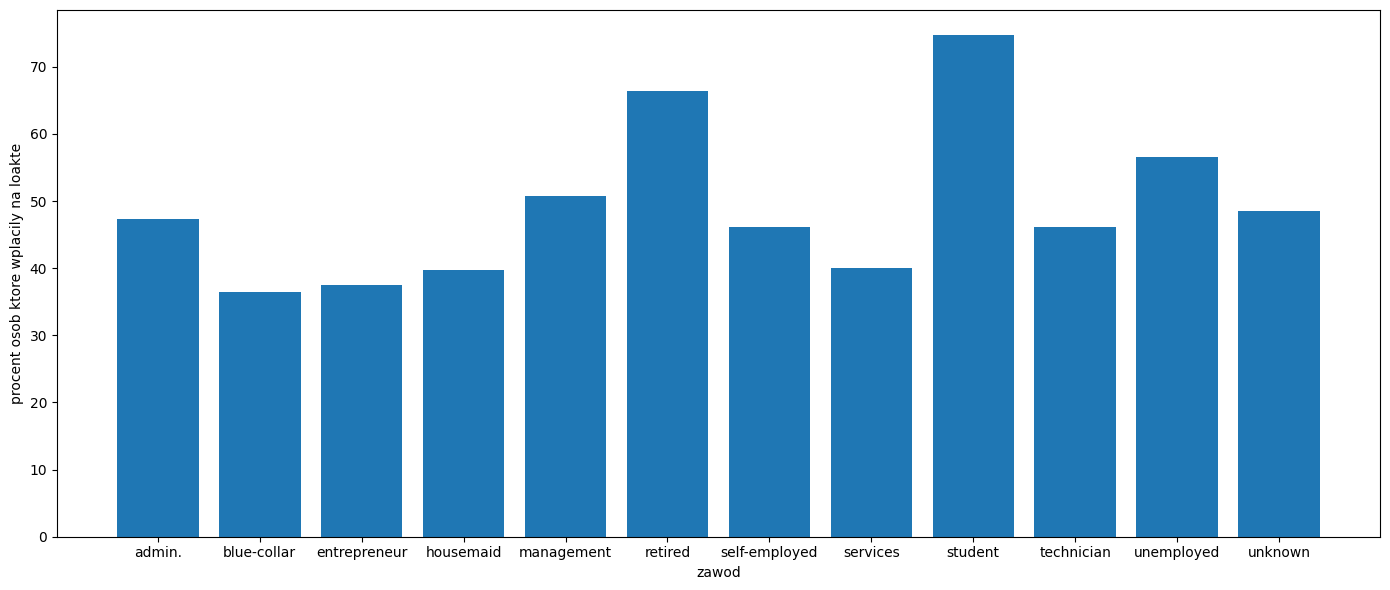

In [34]:
plt.figure(figsize=(14, 6))

plt.bar(x = udzial_lokaty_w_zawodzie.index, height= udzial_lokaty_w_zawodzie)
plt.ylabel('procent osob ktore wplacily na loakte')
plt.xlabel('zawod')

plt.tight_layout()

Najwyzszy odsetek osob otwierajacyh lokaty to studenci oraz emeryci, zas najmniej to przedsiebiorcy i pracownicy fizyczni. Pokazuje to ze studenci szukaja bezpiecznego i prostego sposobu na powiekszenie kapitalu zas emeryci po prostu maja spore oszczednosci, ktorych lepiej nie trzymac bezczynnie, zas niski odsetek osob otwierajacych lokaty u przedsiebiorcow chociazby z tego ze inwestuja oni w bardziej ryzykowne rzeczy takie jak akcje, bo posiadaja wiedze i majatek ktory sa w stanie poswiecic inwestycji bardziej ryzykownej, zas pracownicy fizyczni po prostu moga miec nizszy kapital.